# Constructing EOS and solving TOV equations

This example notebook shows how to construct the equation of state with the metamodel and speed-of-sound extension scheme parametrization used in the paper, as well as solve the TOV equations. 

In [1]:
import matplotlib.pyplot as plt
params = {"text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"],
          "xtick.labelsize": 16,
          "ytick.labelsize": 16,
          "axes.labelsize": 16,
          "legend.fontsize": 16,
          "legend.title_fontsize": 16}
plt.rcParams.update(params)

import jax.numpy as jnp

import jesterTOV
from jesterTOV.eos.draft_metamodel2.metamodel_CSE import MetaModel_with_CSE_EOS_model
from jesterTOV.tov.gr import GRTOVSolver
import jesterTOV.utils as utils

# Equation of state

------------------------------
DURCA densities: {'ye': Array(nan, dtype=float64), 'ym': Array(nan, dtype=float64), 'nb_durca': Array(nan, dtype=float64)}
--- DUrca Threshold Results ---
Ye            : nan
Ymu           : nan
Yp (Total)    : nan
n_b/n_sat     : nan
------------------------------


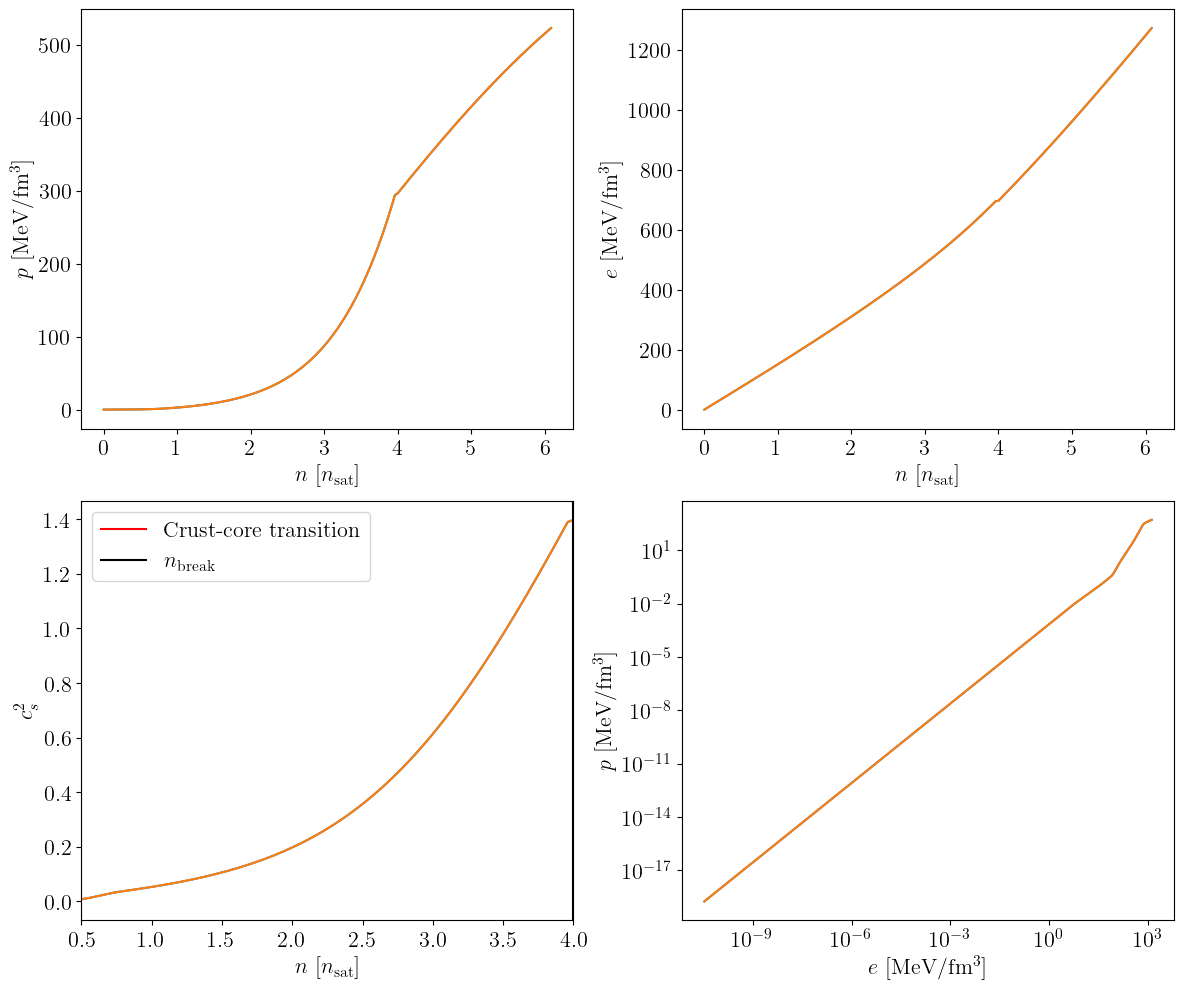

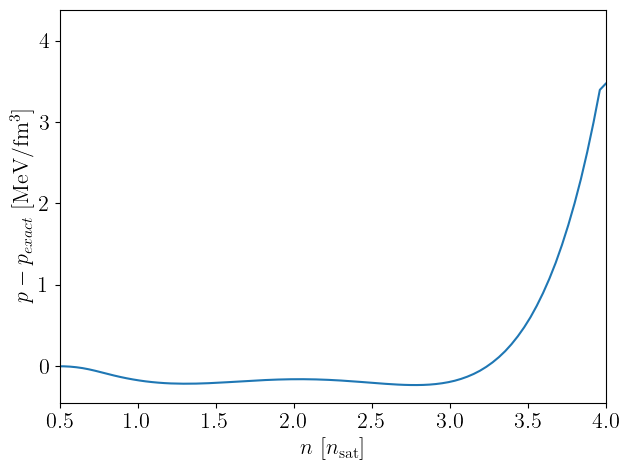

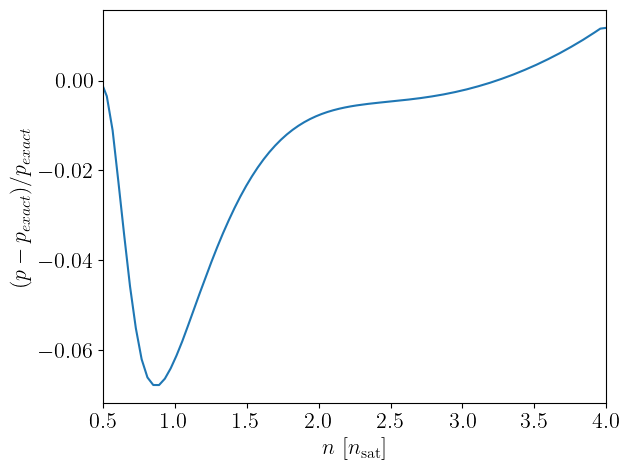

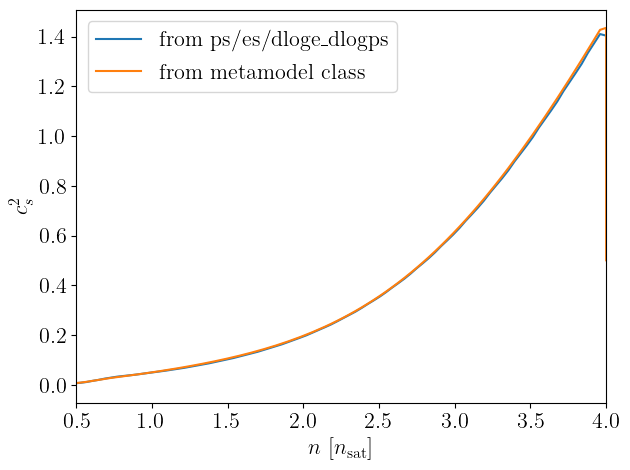

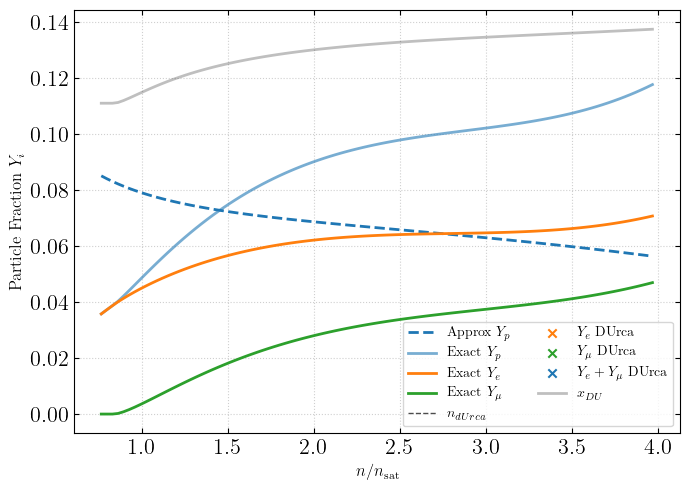

In [2]:
nsat = 0.1578 # nuclear saturation density in fm^-3

# Define the EOS object, here we focus on Metamodel with CSE
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=6.0)
eos_approx = MetaModel_with_CSE_EOS_model(nmax_nsat=6.0, proton_fraction = 'approx')

# Define the nuclear empirical parameters (NEPs) -- all in MeV
NEP_dict = {"E_sat": -16.0, # saturation parameters
            "K_sat": 200.0,
            "Q_sat": 0.0,
            "Z_sat": 0.0,
            "E_sym": 32.0, # symmetry parameters
            "L_sym": 70.0,
            "K_sym": -100.0,
            "Q_sym": 0.0,
            "Z_sym": 0.0,
            }

#from paper
# NEP_dict = {"E_sat": -16.048, # saturation parameters
#             "K_sat": 245.52,
#             "Q_sat": -49.22,
#             "Z_sat": -910.69,
#             "E_sym": 30.0, # symmetry parameters
#             "L_sym": 46.3967,
#             "K_sym": -37.60,
#             "Q_sym": 361.70,
#             "Z_sym": -932.13,
#             }
# SLy dict
# NEP_dict = {"E_sat": -15.97, # saturation parameters
#             "K_sat":  229.9,
#             "Q_sat": -145.1,
#             "Z_sat": -671,
#             "E_sym": 32.01, # symmetry parameters
#             "L_sym": 45.99,
#             "K_sym": -119.6,
#             "Q_sym": 252,
#             "Z_sym": -410,
#             }

# Esat, nsat, Ksat, Qsat, Zsat -15.97, 0.1595, 229.9, -145.1, -671
# Esym, Lsym, Ksym, Qsym, Zsym 32.01,  45.99, -119.6,  252,  -410
# NEP_dict = {"E_sat": -15.97, # saturation parameters
#             "K_sat":  230.0,
#             "Q_sat": -225.0,
#             "Z_sat": -443.0,
#             "E_sym": 32.01, # symmetry parameters
#             "L_sym": 46.00,
#             "K_sym": -120.0,
#             "Q_sym": 350.0,
#             "Z_sym": -690.0,
#             }
# # Esat, nsat, Ksat, Qsat, Zsat -15.97, 0.1595, 230.0, -225.0, -443.0
# Esym, Lsym, Ksym, Qsym, Zsym 32.01,  46.00, -120.0,  350.0, -690.0

# Define the breakdown density -- this is usually between 1-2 nsat
nbreak = 4 * nsat
NEP_dict["nbreak"] = nbreak

# Then we extend with some CSE grid points
ngrids = jnp.array([4.0, 5.0, 6.0, 7.0]) * nsat
cs2grids = jnp.array([0.5, 0.4, 0.3, 0.2]) # speed of sound squared at the grid points

# Now create the EOS -- returns a tuple with most useful EOS quantities
ns, ps, hs, es, dloge_dlogps, mu, cs2, extra = eos.construct_eos(NEP_dict, ngrids, cs2grids, return_extra=True, calculate_durca=True)
n_metamodel_orig = extra['n_metamodel_orig']
proton_fraction = extra['proton_fraction']
e_fraction = extra['e_fraction']
muon_fraction = extra['muon_fraction']
durca_density = extra['durca_density']

ns_approx, ps_approx, hs_approx, es_approx, dloge_dlogps_approx, mu_approx, cs2_approx, extra_approx = eos_approx.construct_eos(NEP_dict, ngrids, cs2grids, return_extra=True)
n_metamodel_orig_approx = extra_approx['n_metamodel_orig']
proton_fraction_approx = extra_approx['proton_fraction']

print("-" * 30)
print("DURCA densities:", durca_density)
ye_durca = durca_density['ye']
ym_durca = durca_density['ym']
n_durca = durca_density['nb_durca']

print(f"--- DUrca Threshold Results ---")
print(f"Ye            : {ye_durca:.6f}")
print(f"Ymu           : {ym_durca:.6f}")
print(f"Yp (Total)    : {ye_durca + ym_durca:.6f}")
print(f"n_b/n_sat     : {n_durca/nsat:.4f}")
print("-" * 30)
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / nsat
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

ns_plots_approx = ns_approx / utils.fm_inv3_to_geometric / nsat
es_plots_approx = es_approx / utils.MeV_fm_inv3_to_geometric
ps_plots_approx = ps_approx / utils.MeV_fm_inv3_to_geometric

ns_plots_approx = ns / utils.fm_inv3_to_geometric / nsat
es_plots_approx = es / utils.MeV_fm_inv3_to_geometric
ps_plots_approx = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.plot(ns_plots_approx, ps_plots_approx)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")

# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.plot(ns_plots_approx, es_plots_approx)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.plot(ns_plots_approx, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(nbreak / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.xlim(0.5,nbreak / nsat)
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.plot(es_plots_approx, ps_plots_approx)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.yscale("log")
plt.xscale("log")
plt.tight_layout()
plt.show()
plt.close()

# Difference
plt.plot(ns_plots, (ps_approx-ps)/ utils.MeV_fm_inv3_to_geometric)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p-p_{exact}$ [MeV/fm$^3$]")
# plt.yscale("log")
# plt.xscale("log")
plt.xlim(0.5,nbreak / nsat)
plt.tight_layout()
plt.show()
plt.close()

# Difference
plt.plot(ns_plots, (ps_approx-ps)/ ps)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$(p-p_{exact})/p_{exact}$ ")
# plt.yscale("log")
# plt.xscale("log")
plt.xlim(0.5,nbreak / nsat)
plt.tight_layout()
plt.show()
plt.close()

plt.plot(ns_approx/ utils.fm_inv3_to_geometric / nsat, ps_approx / es_approx /dloge_dlogps, label = "from ps/es/dloge_dlogps")
plt.plot(ns_approx/ utils.fm_inv3_to_geometric / nsat, cs2_approx, label = "from metamodel class")
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$ ")
# plt.yscale("log")
# plt.xscale("log")
plt.xlim(0.5,nbreak / nsat)
plt.tight_layout()
plt.legend()
plt.show()
plt.close()



plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(n_metamodel_orig / nsat, proton_fraction_approx, 
        ls='--', lw=2, color='tab:blue', label=r"Approx $Y_p$")
ax.plot(n_metamodel_orig_approx / nsat, proton_fraction, 
        ls='-', lw=2, color='tab:blue', alpha=0.6, label=r"Exact $Y_p$")

ax.plot(n_metamodel_orig_approx / nsat, e_fraction, 
        ls='-', lw=2, color='tab:orange', label=r"Exact $Y_e$")
ax.plot(n_metamodel_orig_approx / nsat, muon_fraction, 
        ls='-', lw=2, color='tab:green', label=r"Exact $Y_{\mu}$")

# ax.plot(n_metamodel_orig / nsat, (ye_durca + ym_durca)*n_metamodel_orig / nsat, 
#         ls='--', lw=2, color='tab:blue', label=r"$x^{DU}$")

ax.set_xlabel(r"$n/n_{\rm{sat}}$", fontsize=12)
ax.set_ylabel(r"Particle Fraction $Y_i$", fontsize=12)
ax.axvline(x=n_durca/nsat, color='black', ls='--', linewidth=1.0, alpha=0.7, label=r'$n_{dUrca}$')
ax.scatter(n_durca/nsat, ye_durca, color='tab:orange', marker='x', label=r'$Y_{e}$ DUrca')
ax.scatter(n_durca/nsat, ym_durca, color='tab:green', marker='x', label=r'$Y_{\mu}$ DUrca')
ax.scatter(n_durca/nsat, ye_durca + ym_durca, color='tab:blue', marker='x', label=r'$Y_{e} + Y_{\mu}$ DUrca')

x_e = e_fraction/(e_fraction+muon_fraction)
x_DU = 1/(1+(1+jnp.cbrt(x_e))**3)
ax.plot(n_metamodel_orig_approx / nsat, x_DU, 
        ls='-', lw=2, color='k', alpha = 0.25, label=r"$x_{DU}$")
# Grid is mandatory for reading values!
ax.grid(True, which='major', linestyle=':', alpha=0.6)
ax.legend(frameon=True, loc='best', fontsize=10, ncol=2)
plt.tight_layout()

plt.show()
plt.close()

# Neutron stars

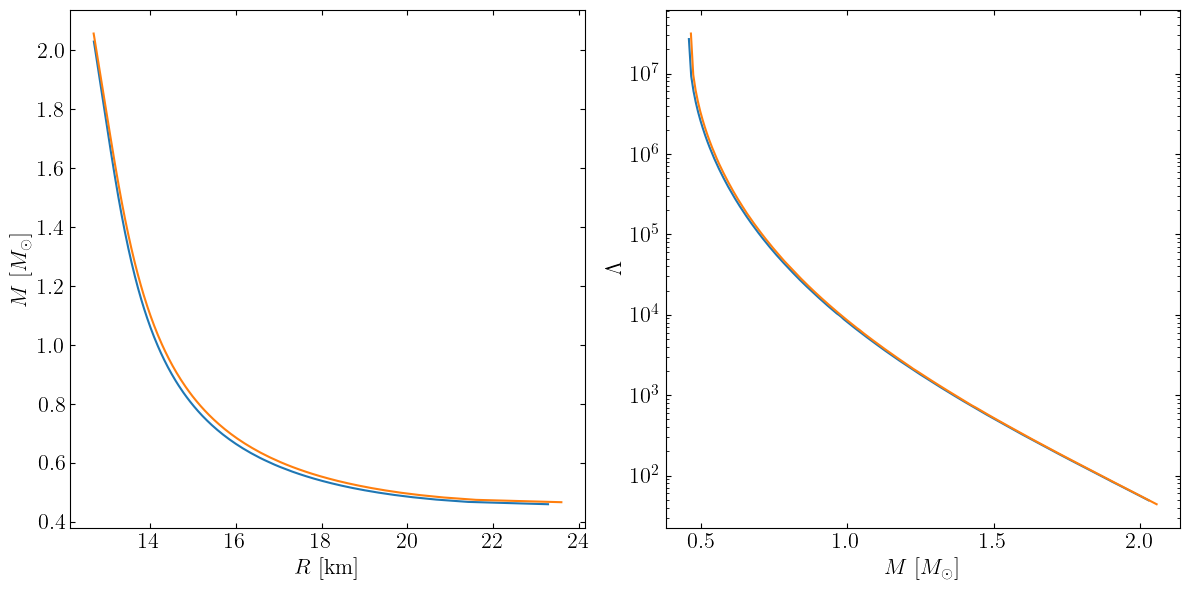

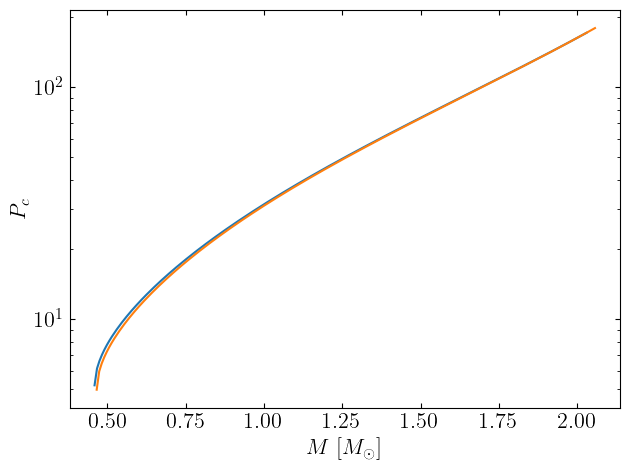

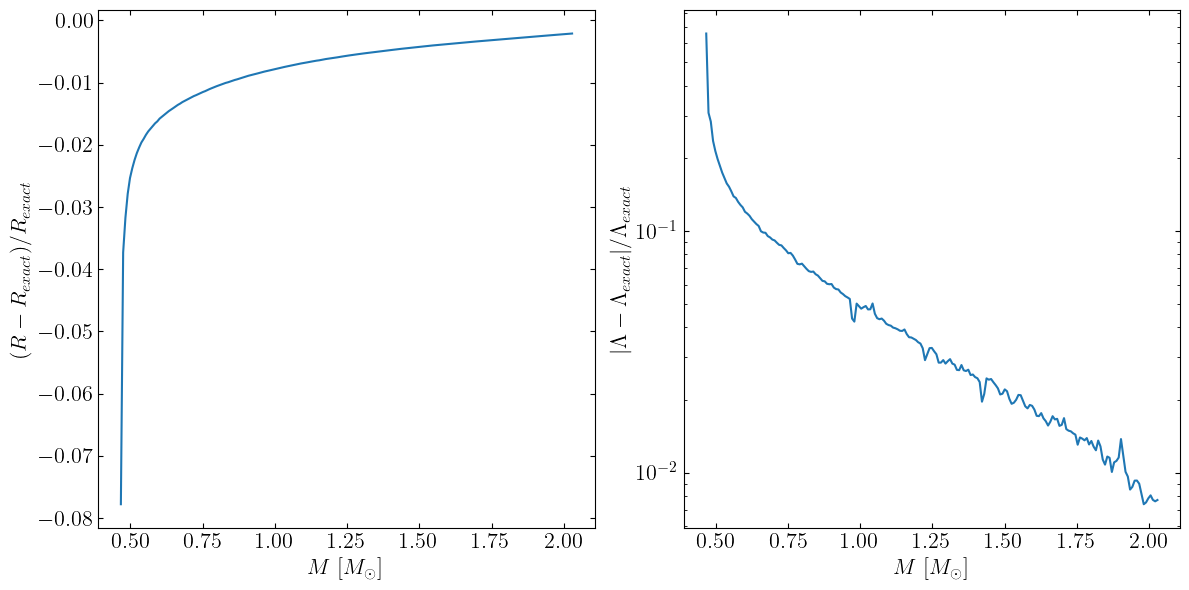

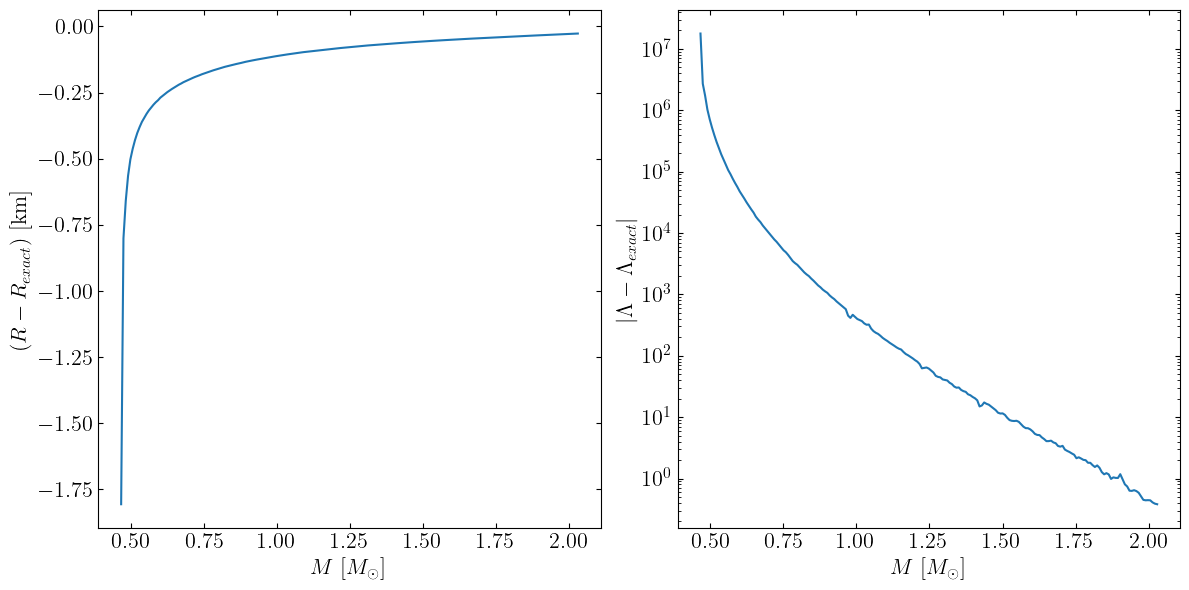

In [3]:
from scipy.interpolate import interp1d
from jesterTOV.tov.data_classes import EOSData

# Create EOSData objects (exact is default, approx is the comparison)
eos_data = EOSData(ns=ns, ps=ps, hs=hs, es=es, dloge_dlogps=dloge_dlogps, cs2=cs2, mu=mu)
eos_data_approx = EOSData(ns=ns_approx, ps=ps_approx, hs=hs_approx, es=es_approx, dloge_dlogps=dloge_dlogps_approx, cs2=cs2_approx, mu=mu_approx)

# Solve TOV equations using the new solver approach:
solver = GRTOVSolver()
family = solver.construct_family(eos_data, ndat=200, min_nsat=1.0)
log10pcs, masses, radii, Lambdas = family.log10pcs, family.masses, family.radii, family.lambdas

family_approx = solver.construct_family(eos_data_approx, ndat=200, min_nsat=1.0)
log10pcs_approx, masses_approx, radii_approx, Lambdas_approx = family_approx.log10pcs, family_approx.masses, family_approx.radii, family_approx.lambdas

pc_max = ps[utils.locate_lowest_non_causal_point(cs2)]
# Interpolate exact solution at approximate mass points
f_exact = interp1d(masses, radii, kind='cubic', bounds_error=False)
f_exact_lam = interp1d(masses, Lambdas, kind='cubic', bounds_error=False)
radii_exact_interp = f_exact(masses_approx)
Lambdas_exact_interp = f_exact_lam(masses_approx)
radius_diff = radii_approx - radii_exact_interp
Lambdas_diff = Lambdas_approx - Lambdas_exact_interp

# Make a plot
plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

# M(R) plot
plt.subplot(121)
plt.plot(radii_approx, masses_approx)
plt.plot(radii, masses)
plt.xlabel(r"$R$ [km]")
plt.ylabel(r"$M$ [$M_\odot$]")

# Lambda(R) plot
plt.subplot(122)
plt.plot(masses_approx, Lambdas_approx)
plt.plot(masses, Lambdas)
plt.xlabel(r"$M$ [$M_\odot$]")
plt.ylabel(r"$\Lambda$")
plt.yscale("log")
plt.tight_layout()
plt.show()
plt.close()

# Pressure - M  plot
plt.plot(masses_approx, jnp.power(10, log10pcs_approx)/utils.MeV_fm_inv3_to_geometric )
plt.plot(masses, jnp.power(10, log10pcs)/ utils.MeV_fm_inv3_to_geometric )
plt.xlabel(r"$M$ [$M_\odot$]")
plt.ylabel(r"$P_c$")
plt.yscale("log")
plt.tight_layout()
plt.show()
plt.close()

# Make a plot
plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

plt.subplot(121)
plt.plot(masses_approx, radius_diff/radii_exact_interp)
plt.ylabel(r"$(R-R_{exact})/R_{exact}$")
plt.xlabel(r"$M$ [$M_\odot$]")


plt.subplot(122)
plt.plot(masses_approx, jnp.abs(Lambdas_diff/Lambdas_exact_interp))
plt.xlabel(r"$M$ [$M_\odot$]")
plt.ylabel(r"$|\Lambda-\Lambda_{exact}| /\Lambda_{exact}$")
plt.yscale("log")
plt.tight_layout()
plt.show()
plt.close()

# Make a plot
plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))
# M(R) plot
plt.subplot(121)
plt.plot(masses_approx, radius_diff)
plt.ylabel(r"$(R-R_{exact})$ [km]")
plt.xlabel(r"$M$ [$M_\odot$]")

# Lambda(R) plot
plt.subplot(122)
plt.plot(masses_approx, jnp.abs(Lambdas_diff))
plt.xlabel(r"$M$ [$M_\odot$]")
plt.ylabel(r"$|\Lambda-\Lambda_{exact}|$")
plt.yscale("log")
plt.tight_layout()
plt.show()
plt.close()

🩹 Applying JIT-safe monkey patch to Crust._preprocess...
✅ Patch applied. You can now run JAX JIT without dynamic shape errors.
Running 10000 EOS constructions in parallel...

NaN Detection Results (Unpacked 8 variables):

Variable 'ps': 505 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Variable 'hs': 565 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Variable 'es': 505 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Variable 'dloge_dlogps': 565 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Variable 'mu': 505 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Variable 'cs2': 505 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Variable 'durca['e_fraction']': 505 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Variable 'durca['proton_fraction']': 505 tests with NaN
  Indices: [16, 24, 64, 70, 78]...

Summary: 9435/10000 successful, 565/10000 failed.
First failing parameters (Index 16):
{'E_sat': -16.02644337345615, 'K_sat': 244.84587458903692, 'Q_sat': 513.64753721

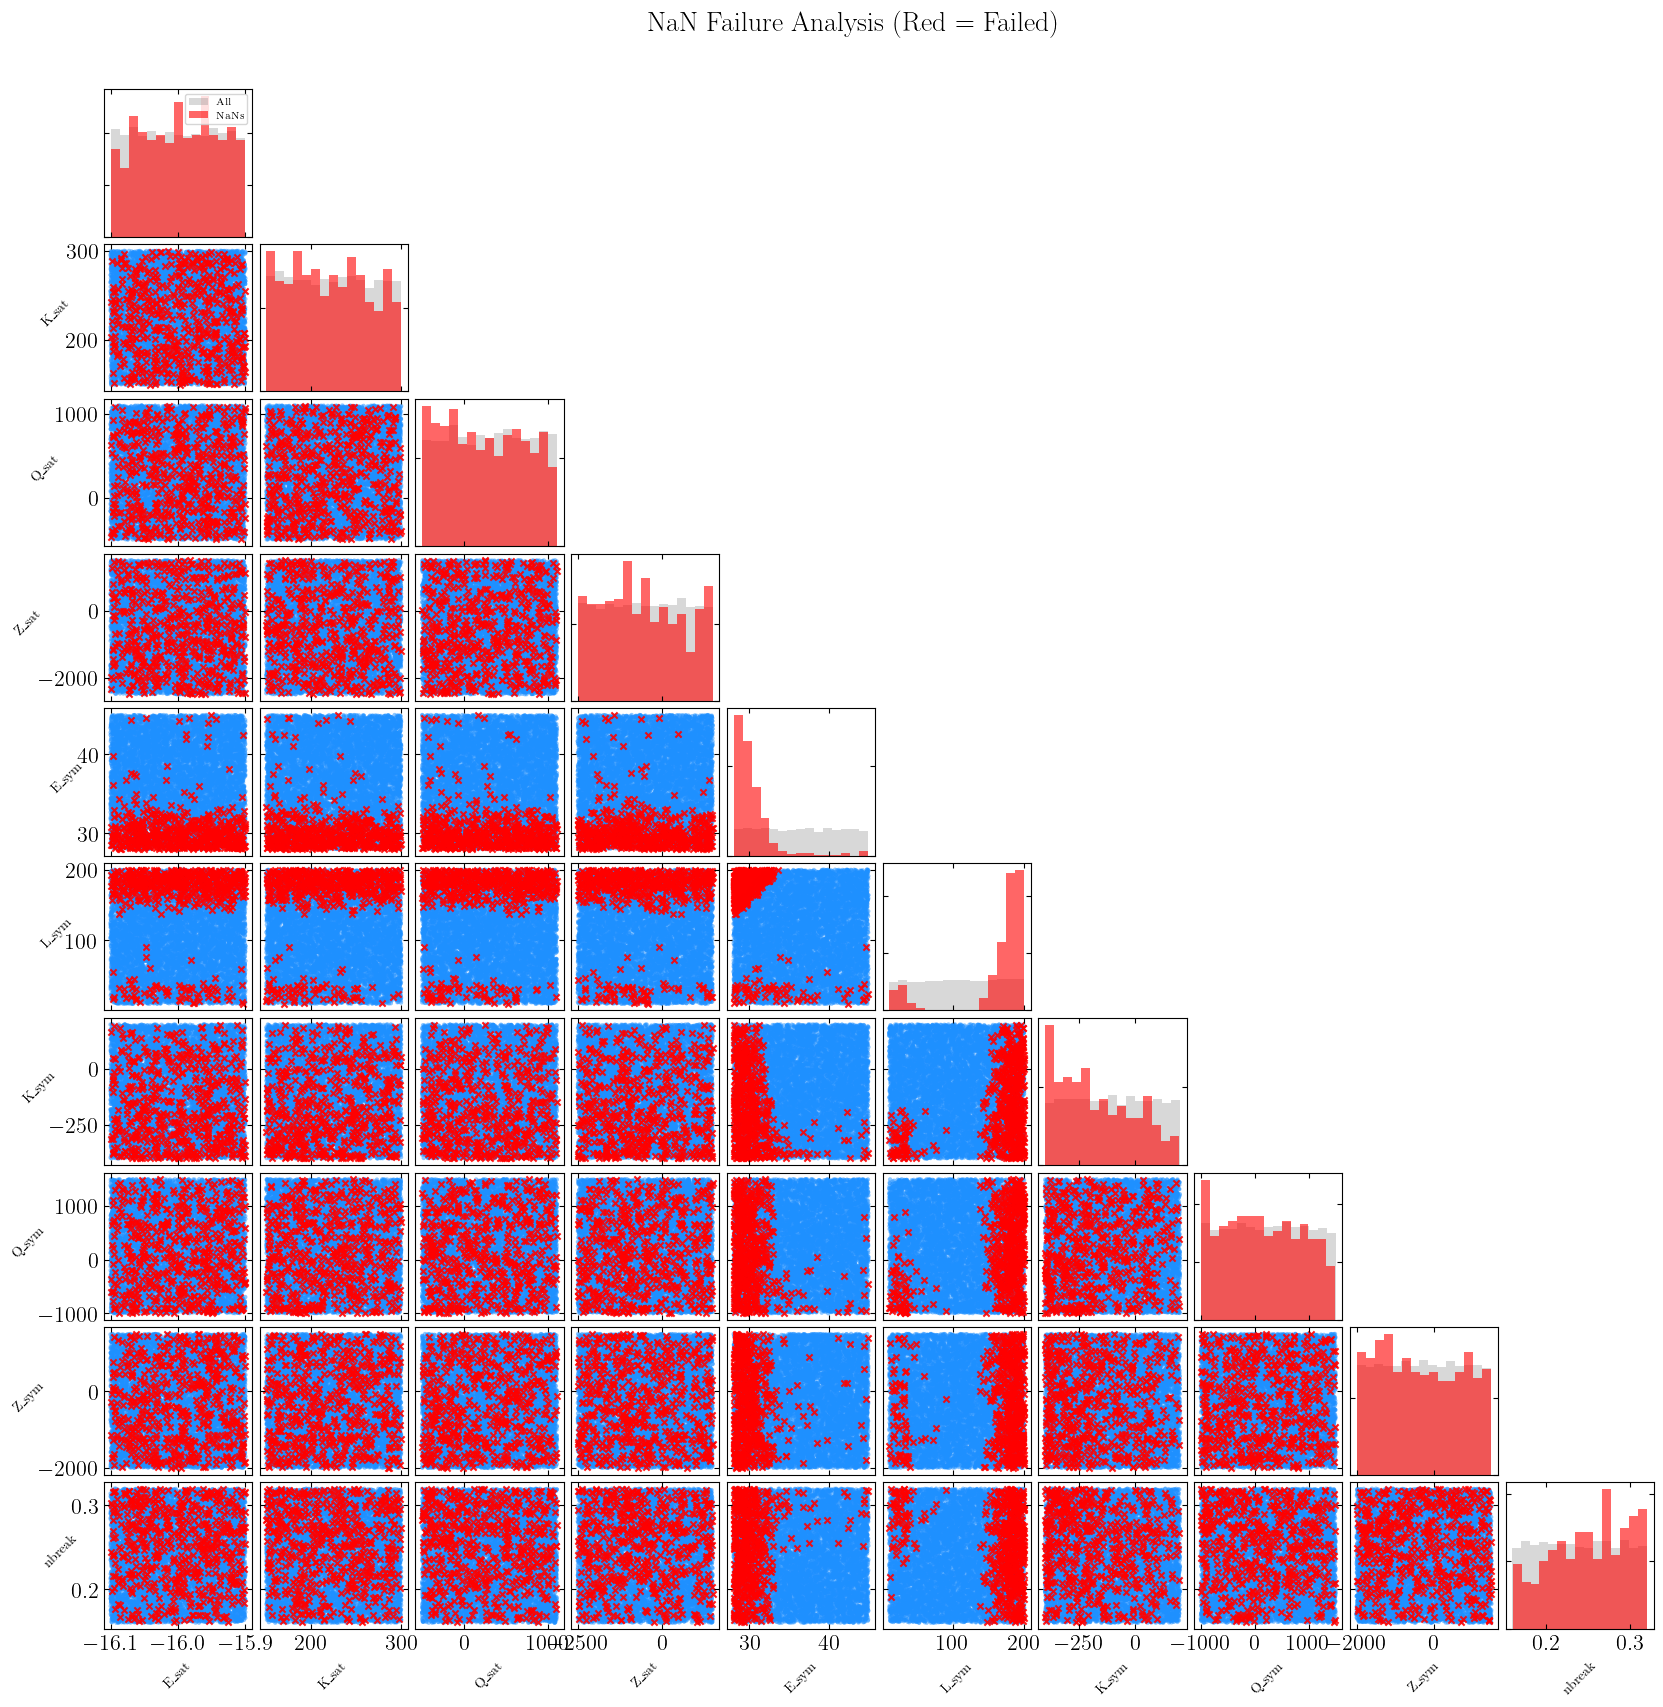

In [12]:
import numpy as np
import jax
import jax.numpy as jnp
# Assuming 'eos' is imported from your module
# import eos 
# ---------------------------------------------------------
# MONKEY PATCH: Fix Dynamic Shape Error without editing files
# ---------------------------------------------------------
from jesterTOV.eos.crust import Crust

# Define a new, JIT-safe preprocessing function
def safe_preprocess(self, n, p, e, min_density, max_density, filter_zero_pressure):
    """
    JIT-Safe Replacement: 
    Instead of slicing the array (which changes shape and crashes JIT),
    we simply return the full data. 
    
    The downstream logic will handle the transition density (nbreak)
    using values, not array sizes.
    """
    # We bypass the 'mask' and 'n[mask]' logic entirely.
    # We return the full arrays so the shape is always static (e.g. 500 points).
    return n, p, e

# Overwrite the method in the loaded class
print("🩹 Applying JIT-safe monkey patch to Crust._preprocess...")
Crust._preprocess = safe_preprocess
print("✅ Patch applied. You can now run JAX JIT without dynamic shape errors.")
# ---------------------------------------------------------
# ---------------------------------------------------------
# 1. Setup Parameters
# ---------------------------------------------------------
nep_ranges = {
    "E_sat": (-16.1, -15.9),
    "K_sat": (150.0, 300.0),
    "Q_sat": (-500.0, 1100.0),
    "Z_sat": (-2500.0, 1500.0),
    "E_sym": (28.0, 45.0),
    "L_sym": (10.0, 200.0),
    "K_sym": (-400.0, 200.0),
    "Q_sym": (-1000.0, 1500.0),
    "Z_sym": (-2000.0, 1500.0),
    "nbreak": (0.16, 0.32),
}

param_names = list(nep_ranges.keys())
n_tests = 10000
np.random.seed(42)

# Generate random parameters (N_tests x N_params)
n_params = len(param_names)
bounds = np.array([nep_ranges[p] for p in param_names])
random_params = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_tests, n_params))

# ---------------------------------------------------------
# 2. KEY FIX: Structure of Arrays (SoA)
# ---------------------------------------------------------
# Instead of a list of 100 dicts, we make ONE dict where 
# each key holds an array of 100 values.
# JAX vmap loves this format.
nep_batch = {
    name: jnp.array(random_params[:, i])
    for i, name in enumerate(param_names)
}

# Constants
nsat = 0.1578
ngrids = jnp.array([4.0, 5.0, 6.0, 7.0]) * nsat
cs2grids = jnp.array([0.5, 0.4, 0.3, 0.2])

# ---------------------------------------------------------
# 3. Vectorized JIT Compilation
# ---------------------------------------------------------
@jax.jit
def run_batch_eos(nep_batch, ngrids, cs2grids):
    """
    Runs construct_eos for the entire batch at once.
    """
    
    # helper: logic for a single EOS
    def single_step(nep):
        return eos.construct_eos(
            nep, ngrids, cs2grids, 
            return_extra=True, 
            calculate_durca=True
        )
    
    # jax.vmap transforms the function to accept batches.
    # in_axes=(0): The first arg (nep) has a batch dimension at axis 0.
    # The other args (ngrids, cs2grids) are treated as constants for the batch.
    batch_fn = jax.vmap(single_step)
    
    return batch_fn(nep_batch)

# ---------------------------------------------------------
# 4. Execution
# ---------------------------------------------------------
print(f"Running {n_tests} EOS constructions in parallel...")

# This runs ONE compiled kernel on the device
# Results are returned already stacked as (n_tests, ...)
results = run_batch_eos(nep_batch, ngrids, cs2grids)

# Unpack directly (results is a tuple of arrays)
# ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all = results

# ---------------------------------------------------------
# 5. NaN Detection (Fixed Unpacking)
# ---------------------------------------------------------

# The *extras will catch the Durca results (8th item) without crashing
ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all, *extras = results

# If you want to check the Durca output for NaNs too, you can grab it:
if extras:
    durca_all = extras[0]
    # Add it to the list for checking
    output_names = ['ns', 'ps', 'hs', 'es', 'dloge_dlogps', 'mu', 'cs2', 'durca']
    all_outputs = [ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all, durca_all]
else:
    output_names = ['ns', 'ps', 'hs', 'es', 'dloge_dlogps', 'mu', 'cs2']
    all_outputs = [ns_all, ps_all, hs_all, es_all, dloge_dlogps_all, mu_all, cs2_all]

print(f"\n{'='*60}")
print(f"NaN Detection Results (Unpacked {len(all_outputs)} variables):")
print(f"{'='*60}")

total_nan_tests = 0
global_nan_mask = jnp.zeros(n_tests, dtype=bool)

for name, arr in zip(output_names, all_outputs):
    
    # CASE 1: The output is a Dictionary (e.g., Durca results)
    if isinstance(arr, dict):
        # We must check every array INSIDE the dictionary
        for sub_key, sub_arr in arr.items():
            full_name = f"{name}['{sub_key}']"
            
            # Skip non-array items inside dict if any
            if not hasattr(sub_arr, 'shape'): 
                continue
                
            # Check for NaNs
            if sub_arr.ndim > 1:
                row_is_nan = jnp.any(jnp.isnan(sub_arr), axis=tuple(range(1, sub_arr.ndim)))
            else:
                row_is_nan = jnp.isnan(sub_arr)
            
            # Update global mask
            global_nan_mask = global_nan_mask | row_is_nan
            
            nan_count = jnp.sum(row_is_nan)
            if nan_count > 0:
                indices = jnp.where(row_is_nan)[0]
                print(f"\nVariable '{full_name}': {nan_count} tests with NaN")
                print(f"  Indices: {indices[:5].tolist()}{'...' if len(indices)>5 else ''}")
        continue

    # CASE 2: The output is a standard JAX Array
    if not hasattr(arr, 'ndim'):
        continue # Skip unknown types

    if arr.ndim > 1:
        # Check all dimensions after the batch dim (axis 0)
        row_is_nan = jnp.any(jnp.isnan(arr), axis=tuple(range(1, arr.ndim)))
    else:
        row_is_nan = jnp.isnan(arr)
        
    global_nan_mask = global_nan_mask | row_is_nan
    
    nan_count = jnp.sum(row_is_nan)
    if nan_count > 0:
        indices = jnp.where(row_is_nan)[0]
        print(f"\nVariable '{name}': {nan_count} tests with NaN")
        print(f"  Indices: {indices[:5].tolist()}{'...' if len(indices)>5 else ''}")

# ---------------------------------------------------------
# Summary Stats
# ---------------------------------------------------------
total_fails = jnp.sum(global_nan_mask)
successful = n_tests - total_fails

print(f"\n{'='*60}")
print(f"Summary: {successful}/{n_tests} successful, {total_fails}/{n_tests} failed.")

if total_fails > 0:
    first_fail_idx = int(jnp.where(global_nan_mask)[0][0])
    print(f"First failing parameters (Index {first_fail_idx}):")
    bad_params = {k: float(v[first_fail_idx]) for k, v in nep_batch.items()}
    print(bad_params)
print(f"{'='*60}")

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 6. Visualization: "The Red Zone" Corner Plot
# ---------------------------------------------------------

# Convert JAX dictionary to standard NumPy matrix (N_samples, N_params)
# We cast to np.array to ensure matplotlib compatibility
param_matrix = np.stack([np.array(nep_batch[p]) for p in param_names], axis=1)
is_bad = np.array(global_nan_mask)
is_good = ~is_bad

print(f"Plotting {len(param_names)}x{len(param_names)} corner plot...")
print(f"🔴 Red points = NaN (Failed)")
print(f"🔵 Blue points = Success")

# Create a grid of subplots
n_dims = len(param_names)
fig, axes = plt.subplots(n_dims, n_dims, figsize=(20, 20))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n_dims):
    for j in range(n_dims):
        ax = axes[i, j]
        
        # X-axis data (Column j)
        x_data = param_matrix[:, j]
        # Y-axis data (Row i)
        y_data = param_matrix[:, i]
        
        # --- DIAGONAL PLOTS (Histograms) ---
        if i == j:
            # Plot distribution of ALL parameters in grey
            ax.hist(x_data, bins=15, color='gray', alpha=0.3, density=True, label='All')
            
            # Overlay distribution of BAD parameters in Red (if any exist)
            if np.sum(is_bad) > 0:
                ax.hist(x_data[is_bad], bins=15, color='red', alpha=0.6, density=True, label='NaNs')
            
            ax.set_yticklabels([]) # Hide Y ticks on diagonal
            
            # Add legend only on the first diagonal
            if i == 0:
                ax.legend(loc='upper right', fontsize='x-small')

        # --- OFF-DIAGONAL PLOTS (Scatter) ---
        else:
            if i < j:
                # Hide upper triangle to keep it clean (standard corner plot style)
                ax.axis('off')
                continue
            
            # Plot GOOD points first (background)
            ax.scatter(x_data[is_good], y_data[is_good], 
                       c='dodgerblue', s=10, alpha=0.5, edgecolor='none')
            
            # Plot BAD points on top (foreground)
            if np.sum(is_bad) > 0:
                ax.scatter(x_data[is_bad], y_data[is_bad], 
                           c='red', s=20, alpha=0.9, marker='x')

        # --- LABELS & TICKS ---
        # Only show x-labels on the bottom row
        if i == n_dims - 1:
            ax.set_xlabel(param_names[j], fontsize=10, rotation=45)
        else:
            ax.set_xticklabels([])

        # Only show y-labels on the left column (and not on diagonal)
        if j == 0 and i != j:
            ax.set_ylabel(param_names[i], fontsize=10, rotation=45)
        else:
            ax.set_yticklabels([])

plt.suptitle(f"NaN Failure Analysis (Red = Failed)", y=0.92, fontsize=20)
plt.show()